# BPTT 与 Two-Pass Exact RTRL：同一个 Global Loss

这个 notebook 只验证一件事：对于同一个五 CV Hodgkin-Huxley 模型、相同参数和完整 trajectory MSE，reverse BPTT 与 two-pass exact RTRL 是否得到相同 loss 和 15 维参数梯度。

Two-pass RTRL 第一遍生成 voltage trace 并自动计算 `partial loss / partial trace`，第二遍重放模型并传播 forward sensitivity。正常结果只返回 scalar loss 和 gradients，不返回 trace 或 diagnostics。

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")
root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "braincell").is_dir()
)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from validation.optim.gradient_correctness.multicv_hh import (
    DT,
    FIVE_CV_TARGET_ROW_SCALES,
    build_multicv_hh_cell,
    simulate_voltage,
)
from braincell.experimental.optim.gradients import (
    build_trajectory_value_and_grad,
)

get_ipython().run_line_magic("matplotlib", "inline")
jax.config.update("jax_enable_x64", True)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 1. 相同目标与两个相同候选 Cell

五个 CV 都包含 Leak、Na-HH 和 K-HH。每个 channel 的 `g_max` scale 按 CV 独立，因此参数方向数为 `3 × 5 = 15`。

In [2]:
NUM_STEPS = 400
times_ms = jnp.arange(NUM_STEPS, dtype=jnp.float64) * DT.to_decimal(u.ms)

with brainstate.environ.context(dt=DT, precision=64):
    target_cell = build_multicv_hh_cell(
        dendrite_segments=(2, 2),
        trainable=False,
        row_scales=FIVE_CV_TARGET_ROW_SCALES,
    )
    target_cell.init_state()
    target_voltage_mv = simulate_voltage(target_cell, times_ms, dt=DT)

    bptt_cell = build_multicv_hh_cell(dendrite_segments=(2, 2), trainable=True)
    bptt_cell.init_state()
    rtrl_cell = build_multicv_hh_cell(dendrite_segments=(2, 2), trainable=True)
    rtrl_cell.init_state()

step_data = (times_ms, target_voltage_mv)
print("target shape:", target_voltage_mv.shape)
print("CV count:", rtrl_cell.n_cv)
print("parameter roots:", tuple(rtrl_cell.trainables.parameters().states()))

target shape: (400, 5)
CV count: 5
parameter roots: ('leak.scale', 'na.scale', 'k.scale')


## 2. 用户直接写完整 Trace Loss

`observation_step`控制采样时刻；这里先读取更新前的 `V_t`，再推进Cell。`trajectory_loss`直接接收完整 `(time, CV)` trace，不需要手工拆成local loss。

In [3]:
def make_engine(cell, method):
    def observation_step(data):
        time_ms, _target_mv = data
        voltage_mv = cell.V.value.to_decimal(u.mV)[0]
        with brainstate.environ.context(t=time_ms * u.ms):
            cell.update()
        return voltage_mv

    def trajectory_loss(voltage_trace, data):
        _times, target_mv = data
        return jnp.mean((voltage_trace - target_mv) ** 2)

    return build_trajectory_value_and_grad(
        cell,
        step=observation_step,
        loss=trajectory_loss,
        method=method,
    )


bptt_engine = make_engine(bptt_cell, "bptt")
rtrl_engine = make_engine(rtrl_cell, "rtrl")
with brainstate.environ.context(dt=DT, precision=64):
    bptt_result = bptt_engine(step_data)
    rtrl_result = rtrl_engine(step_data)

BPTT loss: 818.636210067965
RTRL loss: 818.636210067965
loss absolute error: 0.000e+00
gradient max absolute error: 4.093e-12
gradient max relative error: 2.091e-15


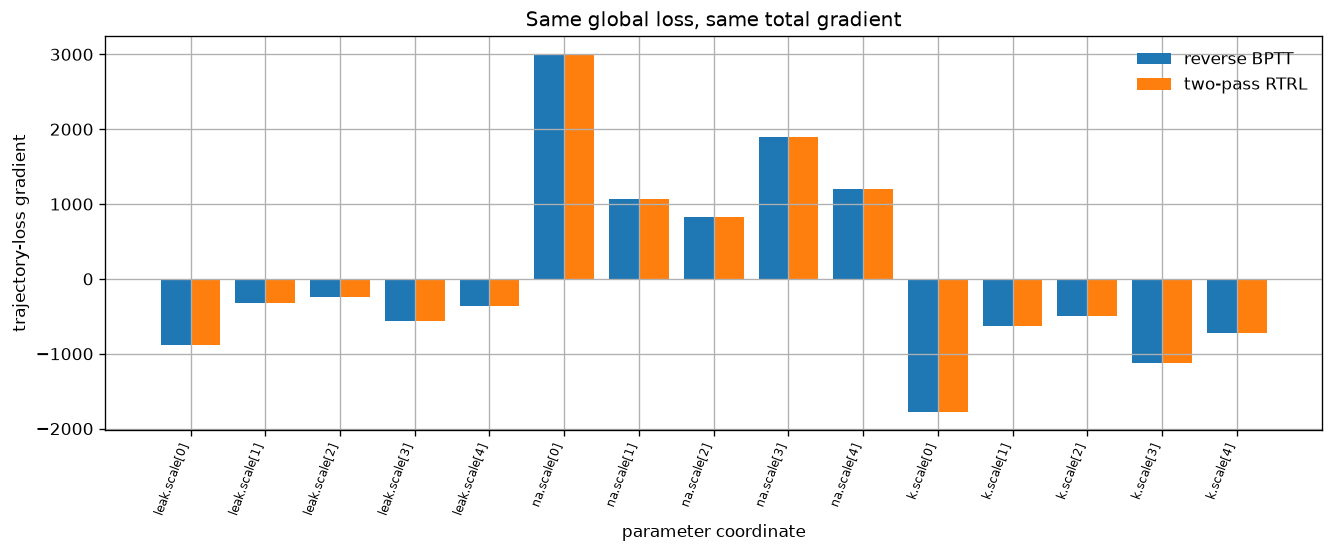

In [4]:
coordinates = rtrl_engine._parameter_coordinates
bptt_gradient = np.asarray(coordinates.flatten({name: bptt_result.gradients[name] for name in coordinates.names}))
rtrl_gradient = np.asarray(coordinates.flatten({name: rtrl_result.gradients[name] for name in coordinates.names}))
absolute_error = np.abs(bptt_gradient - rtrl_gradient)
relative_error = absolute_error / np.maximum(np.abs(bptt_gradient), 1e-30)
labels = [
    f"{name}[{index}]"
    for name, shape in zip(coordinates.names, coordinates.shapes)
    for index in range(int(np.prod(shape)))
]

print(f"BPTT loss: {float(bptt_result.loss):.12f}")
print(f"RTRL loss: {float(rtrl_result.loss):.12f}")
print(f"loss absolute error: {float(jnp.abs(bptt_result.loss - rtrl_result.loss)):.3e}")
print(f"gradient max absolute error: {absolute_error.max():.3e}")
print(f"gradient max relative error: {relative_error.max():.3e}")

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
ax.bar(x - 0.2, bptt_gradient, width=0.4, label="reverse BPTT")
ax.bar(x + 0.2, rtrl_gradient, width=0.4, label="two-pass RTRL")
ax.set(xlabel="parameter coordinate", ylabel="trajectory-loss gradient", title="Same global loss, same total gradient")
ax.set_xticks(x, labels, rotation=70, ha="right", fontsize=7)
ax.legend(frameon=False)
plt.show()

## 结论

- 用户可以直接写依赖完整trace的标量loss。
- BPTT对完整rollout反向传播；RTRL用额外一次primal rollout获得learning signals，再重放forward sensitivity。
- 正常结果只返回loss和named gradients，不返回trace、`S_t`或`L_t` history。
- 可分解的trajectory MSE在性能敏感训练中仍应使用默认local engine；two-pass主要服务依赖未来或跨时间耦合的loss。